In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.process.imputation import get_nan_segs
from cns.process.binning import make_breaks, breaks_to_segments, bin_by_segments, add_cns_loc
from cns.process.segments import segment_difference
from cns.display.label import plot_x_ticks, plot_cytobands
from cns.utils.conversions import tuples_to_segments, genome_to_segments
from cns.utils.assemblies import hg19
from cns.data_utils import load_cns_out, img_path

In [3]:
data = {
    "PCAWG" : load_cns_out("PCAWG_cns_fill.tsv"),
    "TCGA": load_cns_out("TCGA_hg19_cns_fill.tsv"),
    "TRACERx": load_cns_out("TRACERx_cns_fill.tsv"),
}
colors = ["cyan", "purple", "green"]

In [4]:
cyto_breaks = make_breaks("cytobands")
cyto_segments = breaks_to_segments(cyto_breaks)
nans = {k: add_cns_loc(get_nan_segs(v)) for k, v in data.items()}
nans["PCAWG"].head()

,sample_id,chrom,start,end,major_cn,minor_cn,length,mid,cum_mid,total_cn
0,SP101724,chr1,0,17499,NaN,NaN,17499,8749,8749,0.0
23,SP101724,chr1,249250620,249250621,NaN,NaN,1,249250620,249250620,0.0
24,SP101724,chr10,0,94540,NaN,NaN,94540,47270,1680420413,0.0
33,SP101724,chr10,37545108,42605063,NaN,NaN,5059955,40075085,1720448228,0.0
45,SP101724,chr10,135231600,135534747,NaN,NaN,303147,135383173,1815756316,0.0


In [5]:
sums = 1 - (nans["PCAWG"].groupby("sample_id")["length"].sum() / hg19.gen_len)
sum(sums < .8)

1

# NaNs across samples

In [6]:
def plot_nan_hist(ax, nans, genome_length, color, label, query=None, start=0.8):
    if query:
        nans = nans.query(query)
    lengths = nans.groupby("sample_id")["length"].sum()

    mean = 1 - (lengths.mean() / genome_length)
    cutoff = sum((1 - lengths / genome_length) < start)
    
    label = f"{label} (mean={mean:.4f}, cutoff={cutoff:.2f})"

    # plot histogram of lengths / genome_length
    steps = int((1 - start) * 500)
    ax.hist(1 - (lengths / genome_length), bins=np.linspace(start, 1, steps), alpha=0.5, color=color, label=label, density=True)

    ax.legend()

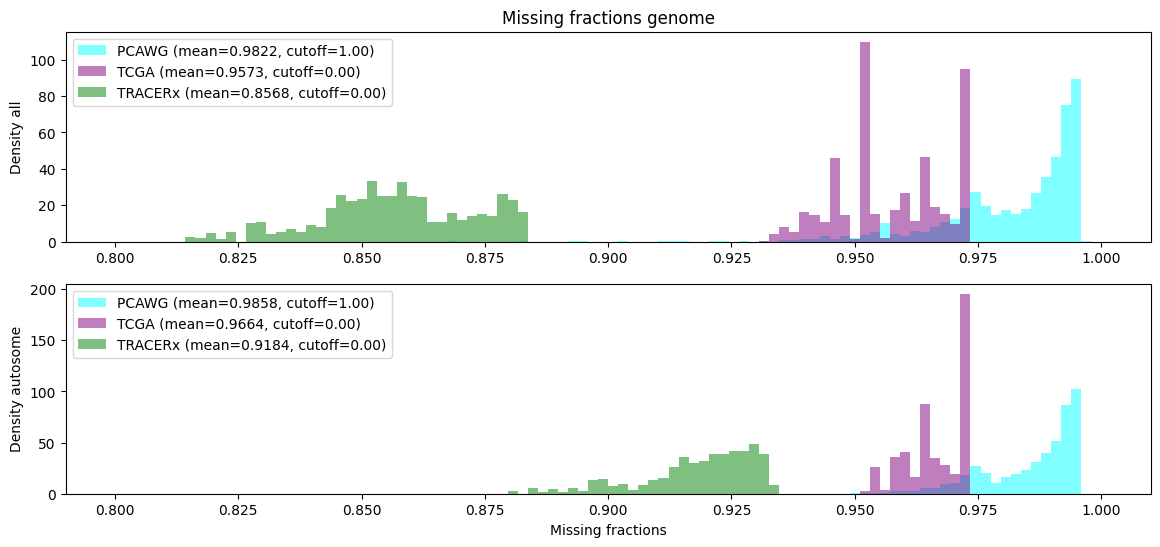

In [7]:
fig, axs = plt.subplots(2, figsize=(14, 6))
yaxes = ["Density all", "Density autosome"]
queries = ["", "chrom != 'chrX' and chrom != 'chrY'"]
for j in range(2):
    for i, (k, v) in enumerate(nans.items()):
        plot_nan_hist(axs[j], v, hg19.gen_len, color=colors[i], label=k, query=queries[j])
        axs[j].set_ylabel(yaxes[j])
axs[0].set_title("Missing fractions genome")
axs[1].set_xlabel("Missing fractions");

# No gap NaNs

In [8]:
breaks = hg19.gaps
gap_segs = tuples_to_segments(breaks)
sel_segs = segment_difference(genome_to_segments(), gap_segs)
no_sex_q = "chrom != 'chrX' and chrom != 'chrY'"
no_gap_nans = {}
for i, (k, v) in enumerate(nans.items()):
	sel_regs = bin_by_segments(v, sel_segs, fun_type=None)
	no_gap_nans[k] = add_cns_loc(get_nan_segs(sel_regs))

Binned into 116236 CNS.                                        
Binned into 1291333 CNS.                                        
Binned into 565826 CNS.                                        


In [9]:
total_gap = sum([seg[2] - seg[1] for seg in gap_segs])
reduced = hg19.gen_len - total_gap
reduced / hg19.gen_len

0.9242993455675995

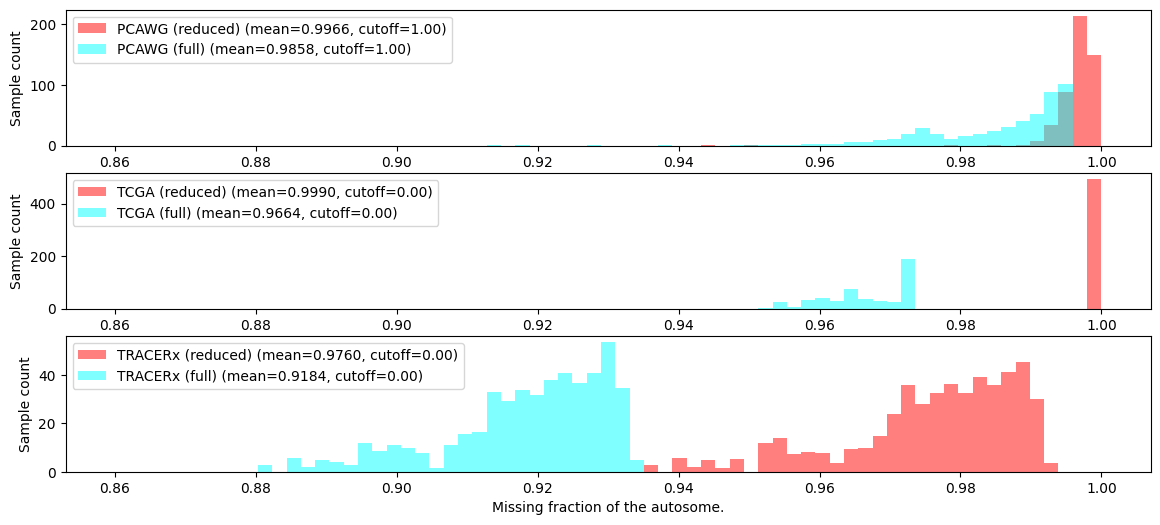

In [14]:
fig, axs = plt.subplots(3, figsize=(14, 6))
for i, (k, v) in enumerate(nans.items()):
	plot_nan_hist(axs[i], no_gap_nans[k], reduced, color="red", label=k + " (reduced)", query=no_sex_q, start=.86)
	plot_nan_hist(axs[i], v, hg19.gen_len, color="cyan", label=k + " (full)", query=no_sex_q, start=.86)
	axs[i].set_ylabel("Sample count")
axs[2].set_xlabel("Missing fraction of the autosome.")

# save to file in img_path with tight layout
plt.savefig(f'{img_path}/missing_fraction_autosome.png', bbox_inches='tight', dpi=200)
plt.savefig(f'{img_path}/missing_fraction_autosome.pdf', bbox_inches='tight', dpi=200)

In [ ]:
no_gap_nans[k]

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn,length,mid,cum_mid
0,CRUK0001_SU_T1-R1,chr1,10000,177417,NaN,NaN,0.0,167417,93708,93708
1,CRUK0001_SU_T1-R1,chr1,227417,267719,NaN,NaN,0.0,40302,247568,247568
2,CRUK0001_SU_T1-R1,chr1,317719,471368,NaN,NaN,0.0,153649,394543,394543
3,CRUK0001_SU_T1-R1,chr1,521368,762272,NaN,NaN,0.0,240904,641820,641820
4,CRUK0001_SU_T1-R1,chr1,3800149,3800217,NaN,NaN,0.0,68,3800183,3800183
...,...,...,...,...,...,...,...,...,...,...
565821,CRUK0893_SU_T1-R2,chrX,120063235,143507324,NaN,NaN,0.0,23444089,131785279,3012818565
565822,CRUK0893_SU_T1-R2,chrX,143557324,148906424,NaN,NaN,0.0,5349100,146231874,3027265160
565823,CRUK0893_SU_T1-R2,chrX,148956424,149032062,NaN,NaN,0.0,75638,148994243,3030027529
565824,CRUK0893_SU_T1-R2,chrX,149082062,152277099,NaN,NaN,0.0,3195037,150679580,3031712866
